# Instructor Effectiveness Modeling (EdTech Context)
**Role:** Data Science / AI Content Specialist Intern
**Dataset:** `instructor_effectiveness_dataset_2000_rows.csv` (2000 batch-level records)

This notebook analyzes learner outcome, engagement, and feedback data from an EdTech
platform to define, model, and interpret **instructor effectiveness**.

**Structure**
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Defining Instructor Effectiveness
4. Aggregating Batch Data to Instructor Level
5. Feature Engineering for Modeling
6. Machine Learning Model
7. Model Evaluation
8. Interpretation of Results
9. Mandatory Analysis Questions


## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, f1_score)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


In [2]:
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows_-_instructor_effectiveness_dataset_2000_rows_csv.csv")
print("Shape:", df.shape)
df.head()


Shape: (2000, 12)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   str    
 1   instructor_id               2000 non-null   str    
 2   course_id                   2000 non-null   str    
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), str(3)
memory usage: 187.6 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


## 2. Exploratory Data Analysis (EDA)

Each row is one **course batch**. Instructors can appear in multiple rows (multiple
batches, possibly multiple courses). Before we can talk about "instructor effectiveness"
we need to understand batch-level patterns first.


### 2.1 Missing Values & Basic Sanity Checks

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate batch_id rows:", df.duplicated(subset=["batch_id"]).sum())
print("Number of unique instructors:", df["instructor_id"].nunique())
print("Number of unique courses:", df["course_id"].nunique())
print("Number of batches per instructor -> min/median/max:",
      df.groupby("instructor_id").size().min(),
      df.groupby("instructor_id").size().median(),
      df.groupby("instructor_id").size().max())


Missing values per column:
batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

Duplicate batch_id rows: 0
Number of unique instructors: 120
Number of unique courses: 25
Number of batches per instructor -> min/median/max: 7 17.0 31


**Observation:** There are no missing values and no duplicate `batch_id`s, so the
dataset is already clean. Every instructor has taught **at least 7 batches**, so we won't
face a "single-batch instructor" edge case — but the number of batches per instructor
still varies quite a bit (7 to 31), which we account for later when aggregating.


### 2.2 Distributions of Key Metrics

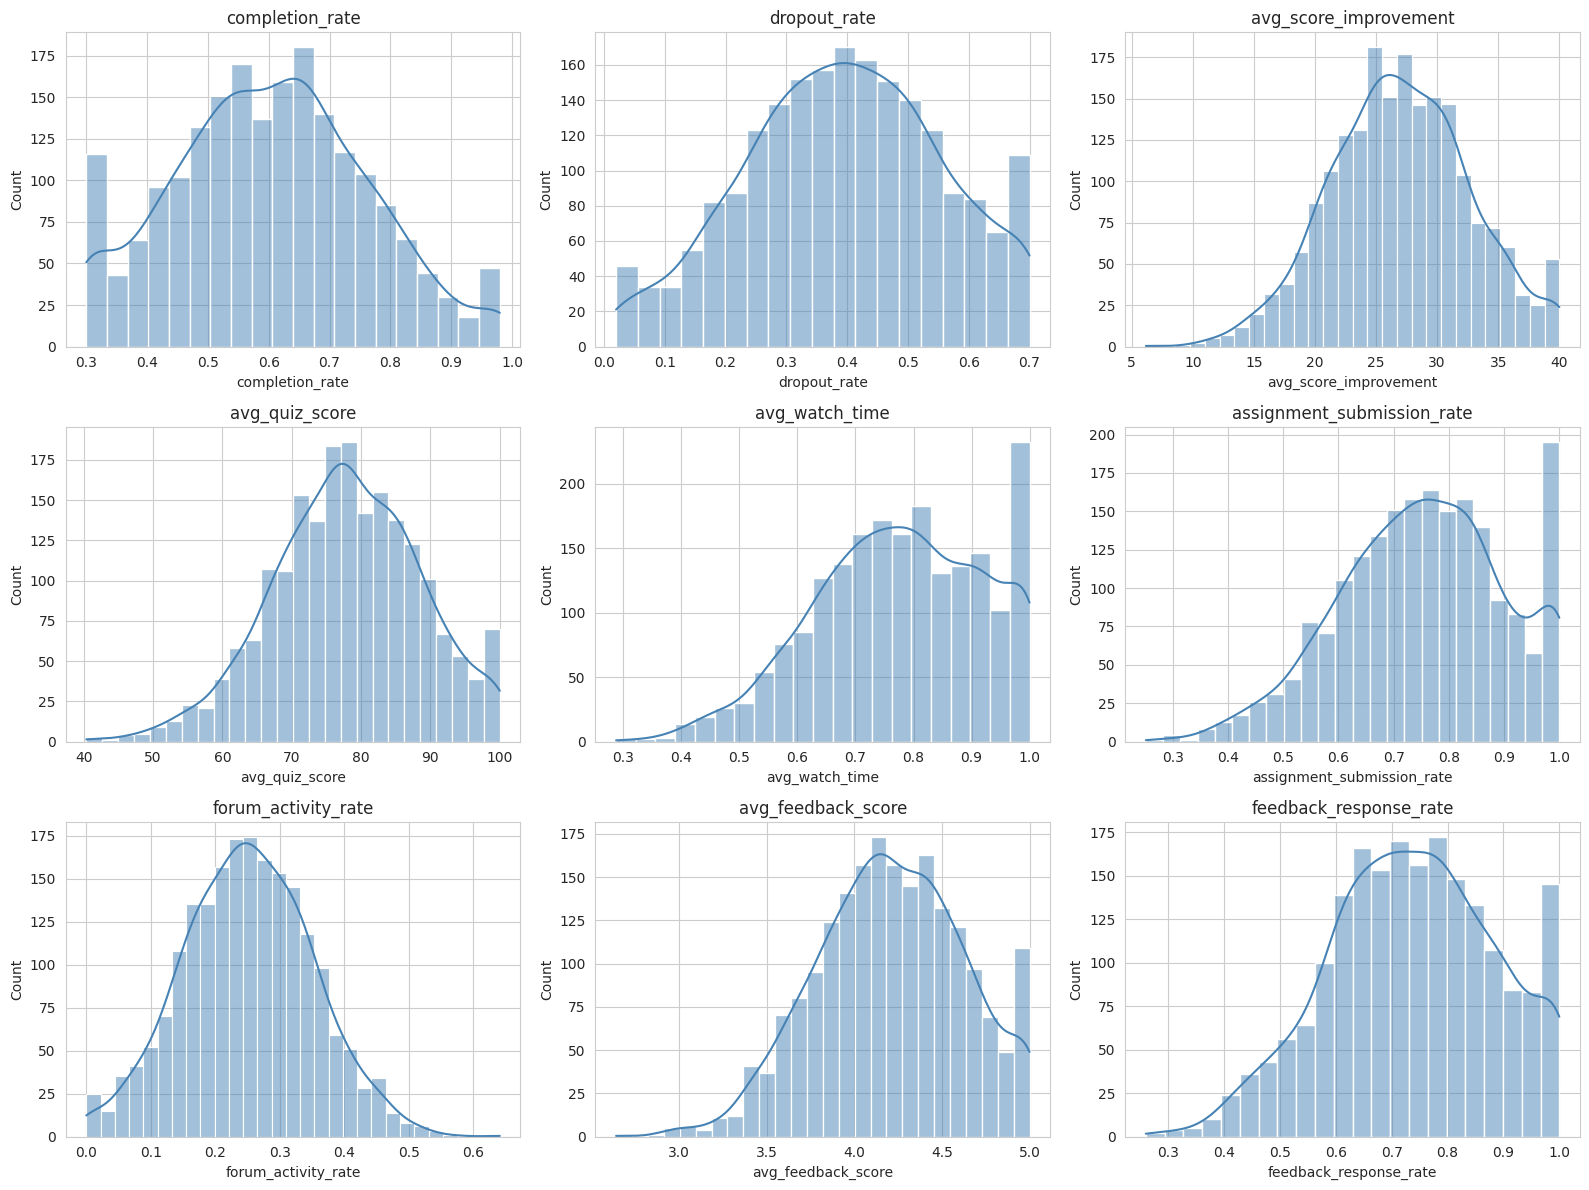

In [6]:
metrics = ["completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score",
           "avg_watch_time", "assignment_submission_rate", "forum_activity_rate",
           "avg_feedback_score", "feedback_response_rate"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, metrics):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Observations:**
- `completion_rate` and `dropout_rate` are (unsurprisingly) roughly mirror images of each
  other and both look fairly normally distributed around 0.5-0.6, suggesting no single
  batch dominates the data or is clipped at the boundaries in a suspicious way.
- `avg_quiz_score` and `avg_feedback_score` are left of center / slightly skewed towards
  higher values, which is typical for course feedback and assessment data.
- None of the distributions show obvious data entry errors (e.g. values outside their
  documented range like `completion_rate` > 1 or `avg_feedback_score` > 5).


### 2.3 Correlation Structure

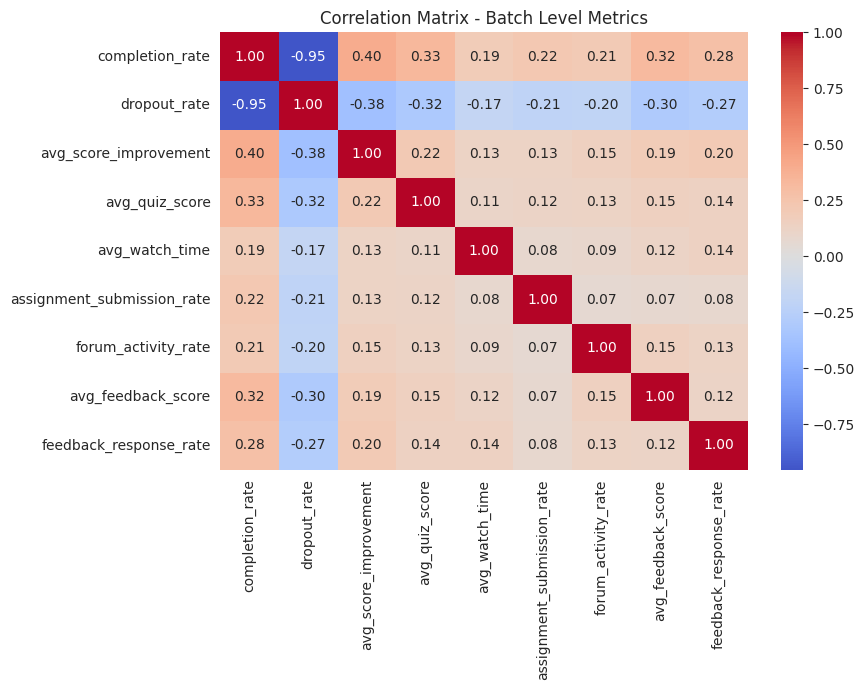

In [7]:
corr = df[metrics].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Batch Level Metrics")
plt.tight_layout()
plt.show()


**Observations:**
- `completion_rate` and `dropout_rate` are strongly negatively correlated (as expected -
  they are near-complements of each other). This tells us **we should not treat them as
  two fully independent signals** when building an effectiveness score, or we will
  effectively double-count the same information.
- Engagement metrics (`avg_watch_time`, `assignment_submission_rate`,
  `forum_activity_rate`) show mild positive correlation with outcome metrics
  (`completion_rate`, `avg_quiz_score`), which supports the intuition that engaged
  learners tend to perform better — but the correlations are moderate, not extreme, so
  engagement alone won't perfectly predict outcomes.
- Feedback metrics (`avg_feedback_score`, `feedback_response_rate`) correlate only weakly
  with hard outcome metrics. This is an early hint that **feedback ratings and actual
  learning outcomes are somewhat distinct constructs** — something we revisit in the
  "misleading variables" discussion later.


### 2.4 Relationship Between Engagement and Outcomes

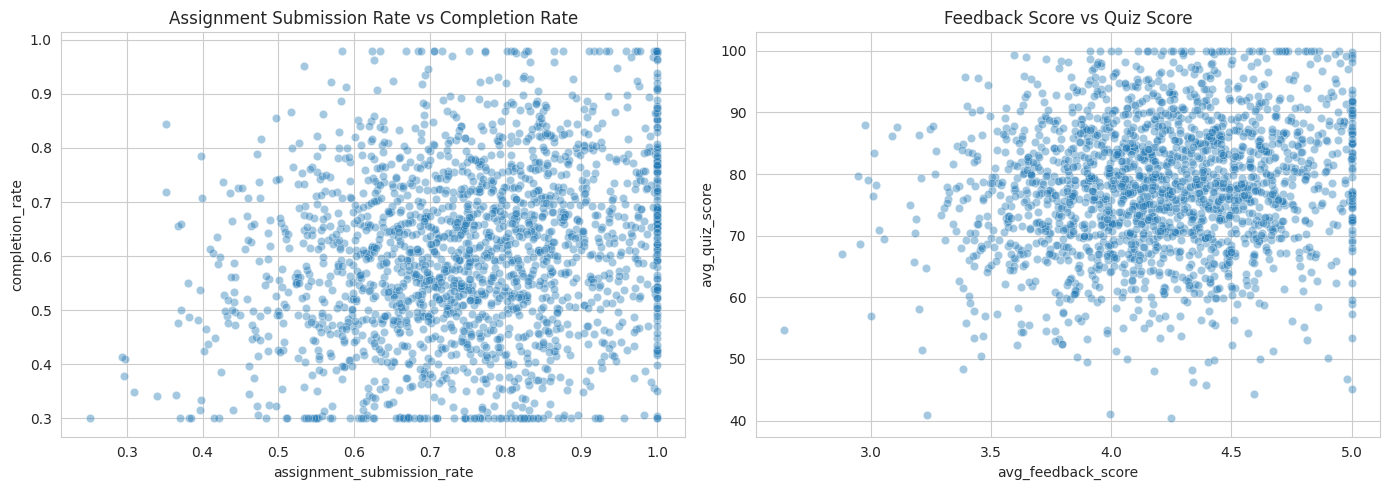

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="assignment_submission_rate", y="completion_rate",
                 alpha=0.4, ax=axes[0])
axes[0].set_title("Assignment Submission Rate vs Completion Rate")

sns.scatterplot(data=df, x="avg_feedback_score", y="avg_quiz_score",
                 alpha=0.4, ax=axes[1])
axes[1].set_title("Feedback Score vs Quiz Score")
plt.tight_layout()
plt.show()


**Observation:** There's a visible positive trend between assignment submission and
completion, but a much weaker / noisier relationship between feedback scores and quiz
performance. Learners can rate a course highly for reasons unrelated to how much they
actually learned (e.g. instructor likability, production quality), reinforcing that
feedback should be treated as a *supporting* signal, not a stand-in for learning outcomes.


### 2.5 Do Courses Differ Systematically?

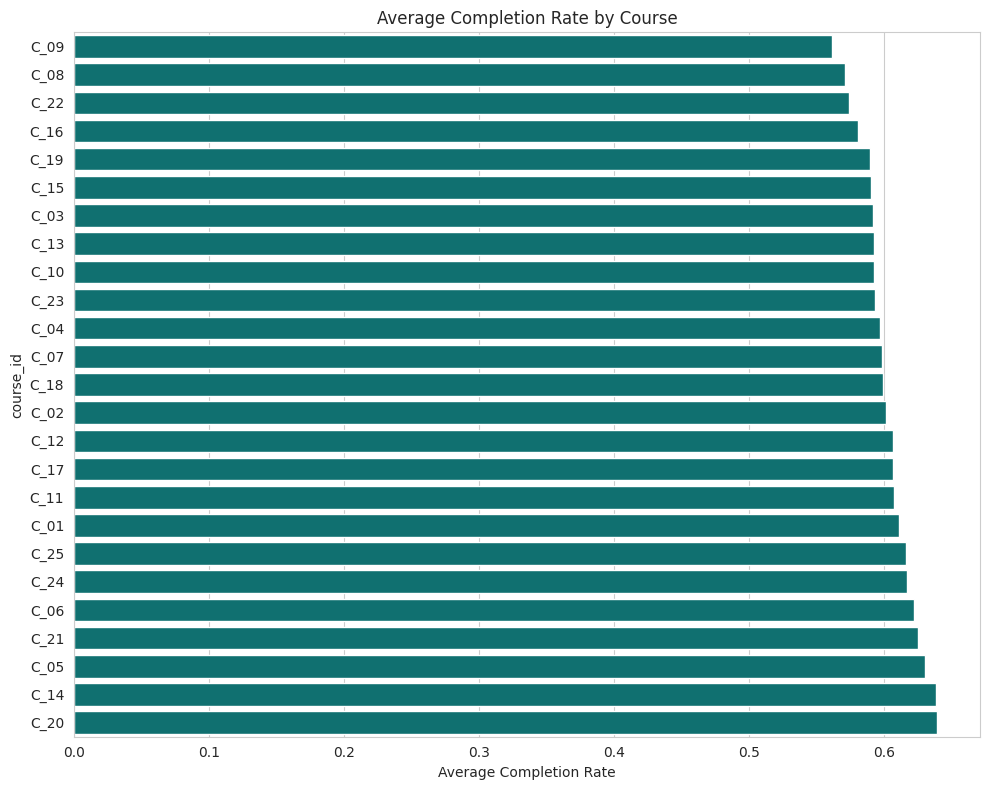

In [9]:
course_avg = df.groupby("course_id")[["completion_rate", "avg_quiz_score"]].mean().sort_values("completion_rate")
plt.figure(figsize=(10, 8))
sns.barplot(x=course_avg["completion_rate"], y=course_avg.index, color="teal")
plt.title("Average Completion Rate by Course")
plt.xlabel("Average Completion Rate")
plt.tight_layout()
plt.show()


**Observation:** Average completion rate varies noticeably by course. This matters
because an instructor teaching a naturally "harder" or less popular course could look
less effective purely due to course difficulty, not their own teaching quality. This is
a **confound** we flag explicitly in the mandatory questions section — with more data we
would ideally adjust for course-level difficulty (e.g. course fixed effects) before
scoring instructors.


## 3. Defining Instructor Effectiveness

### 3.1 Our Definition

We define **Instructor Effectiveness** primarily in terms of **learner outcomes** — the
things a good instructor should most directly influence: did learners finish the course,
did they improve, and did they learn the material. We deliberately **do not** fold
engagement and feedback metrics directly into the effectiveness *label*, for two reasons:

1. **Conceptual clarity** — outcomes (completion, dropout, score improvement, quiz score)
   are the closest available proxy for *actual learning*, which is what "effectiveness"
   should mean. Engagement and feedback are useful signals, but they are one step removed
   (a learner can watch every video and still not master the material; a course can get
   great ratings without producing strong learning gains, as hinted by EDA above).
2. **Avoiding label leakage in modeling** — since we later want the ML model to *predict*
   effectiveness from other signals, defining the score using variables like engagement
   and feedback would make those the same signals used to construct the label,
   turning the "prediction" task into a tautology. Instead, we use **engagement and
   feedback metrics as the model's predictors**, so the model answers a genuinely useful
   question: *"Can we predict outcome-based effectiveness from earlier/cheaper-to-observe
   engagement and feedback signals?"* This is directly useful for an EdTech product,
   which typically has engagement and feedback data *before* final outcome data is fully
   available.

### 3.2 The Formula

We combine 4 outcome metrics into a single **Effectiveness Score** using standardized
(z-scored) values, so that each metric contributes on a comparable scale regardless of
its original range:

```
effectiveness_score = 0.30 * z(completion_rate)
                     + 0.30 * z(-dropout_rate)         # inverted: lower dropout is better
                     + 0.20 * z(avg_score_improvement)
                     + 0.20 * z(avg_quiz_score)
```

**Why these weights?**
- `completion_rate` and `dropout_rate` (inverted) get the highest combined weight (60%)
  because *finishing the course* is the most fundamental outcome a platform cares about —
  however, since they are strongly negatively correlated with each other (see EDA), we
  split 30/30 rather than giving completion 60% alone, so we're not overweighting a
  single near-duplicated signal.
- `avg_score_improvement` and `avg_quiz_score` each get 20% because they measure
  *learning quality*, which matters but is a secondary signal to whether learners
  actually stuck around to receive that learning.

This weighting is a **judgment call**, not a universal truth — a different EdTech team
might reasonably weight quiz performance higher. We state it explicitly so it is easy to
audit and adjust.

### 3.3 From Score to Tiers

We convert the (instructor-level, see Section 4) score into 3 tiers using **tertiles**
(33rd / 67th percentile cut points) rather than fixed thresholds, since the score itself
is a relative (z-score-based) quantity with no natural absolute cutoff:

- **Low** — bottom third of instructors
- **Medium** — middle third
- **High** — top third

Tertiles keep classes roughly balanced, which is helpful for a small-sample classification
task (120 instructors) and mirrors how such scores are typically communicated in
performance-management contexts ("bottom/middle/top third").


## 4. Aggregating Batch Data to Instructor Level

Since each instructor teaches multiple batches (possibly across different courses), we
must roll batch-level rows up into **one row per instructor** before we can score and
model instructor effectiveness.

**Aggregation choices:**
- **Mean** is our primary aggregator for all rate/score metrics — it summarizes "typical"
  instructor performance and is easy to interpret.
- **Standard deviation** is computed for the engagement metrics, to capture
  *consistency* — an instructor whose engagement numbers swing wildly between batches is
  arguably a different profile than one who is reliably steady, even at the same average.
- **Count of batches taught** (`batches_taught`) is kept as an experience/exposure
  feature, and **count of distinct courses taught** (`courses_taught`) as a versatility
  feature.
- We do **not** separately weight instructors with few vs. many batches when computing
  the mean (a simple unweighted mean per instructor, since every batch is roughly
  learner-cohort-sized already, not learner-count-weighted). In a production setting,
  ideally we would weight by the number of learners in each batch, but learner-count is
  not available in this dataset, so we treat each batch as an equally-important
  observation of that instructor's performance. We do keep `batches_taught` as an
  explicit feature so the model / analyst can see how much evidence backs each
  instructor's numbers — instructors with very few batches (e.g. 7-8) have noisier
  estimates than those with 20+, which we call out as a limitation later.


In [10]:
outcome_cols = ["completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score"]
engagement_cols = ["avg_watch_time", "assignment_submission_rate", "forum_activity_rate"]
feedback_cols = ["avg_feedback_score", "feedback_response_rate"]

agg_dict = {}
for c in outcome_cols:
    agg_dict[c] = "mean"
for c in engagement_cols:
    agg_dict[c] = ["mean", "std"]
for c in feedback_cols:
    agg_dict[c] = "mean"

instructor_df = df.groupby("instructor_id").agg(agg_dict)
# flatten multi-level column names
instructor_df.columns = ["_".join(col).strip("_") if isinstance(col, tuple) else col
                          for col in instructor_df.columns]
instructor_df = instructor_df.rename(columns={c: f"{c}_mean" for c in outcome_cols + feedback_cols})

# batches / courses taught
instructor_df["batches_taught"] = df.groupby("instructor_id").size()
instructor_df["courses_taught"] = df.groupby("instructor_id")["course_id"].nunique()

# std of engagement metrics can be NaN for instructors with 1 batch; fill with 0 (no variability observed)
std_cols = [c for c in instructor_df.columns if c.endswith("_std")]
instructor_df[std_cols] = instructor_df[std_cols].fillna(0)

instructor_df = instructor_df.reset_index()
print(instructor_df.shape)
instructor_df.head()


(120, 15)


,instructor_id,completion_rate_mean,dropout_rate_mean,avg_score_improvement_mean,avg_quiz_score_mean,avg_watch_time_mean,avg_watch_time_std,assignment_submission_rate_mean,assignment_submission_rate_std,forum_activity_rate_mean,forum_activity_rate_std,avg_feedback_score_mean,feedback_response_rate_mean,batches_taught,courses_taught
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.131532,0.726893,0.145189,0.240551,0.094695,4.217743,0.694858,25,16
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.112701,0.774394,0.141096,0.289610,0.088573,4.343002,0.784338,20,10
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.158280,0.779606,0.121712,0.296224,0.082414,4.450034,0.812132,18,14
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.126603,0.758317,0.135790,0.226259,0.093217,4.076410,0.721460,17,10
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.108567,0.876942,0.102360,0.333519,0.105278,4.202516,0.784197,19,13


### 4.1 Building the Effectiveness Score and Tiers

In [11]:
from scipy.stats import zscore

instructor_df["z_completion"] = zscore(instructor_df["completion_rate_mean"])
instructor_df["z_dropout_inv"] = zscore(-instructor_df["dropout_rate_mean"])
instructor_df["z_score_improve"] = zscore(instructor_df["avg_score_improvement_mean"])
instructor_df["z_quiz"] = zscore(instructor_df["avg_quiz_score_mean"])

instructor_df["effectiveness_score"] = (
    0.30 * instructor_df["z_completion"] +
    0.30 * instructor_df["z_dropout_inv"] +
    0.20 * instructor_df["z_score_improve"] +
    0.20 * instructor_df["z_quiz"]
)

# Tertile-based tiers
q33, q67 = instructor_df["effectiveness_score"].quantile([0.33, 0.67])

def tier_from_score(s):
    if s <= q33:
        return "Low"
    elif s <= q67:
        return "Medium"
    else:
        return "High"

instructor_df["effectiveness_tier"] = instructor_df["effectiveness_score"].apply(tier_from_score)

print(instructor_df["effectiveness_tier"].value_counts())
instructor_df[["instructor_id", "effectiveness_score", "effectiveness_tier"]].sort_values(
    "effectiveness_score", ascending=False).head(10)


effectiveness_tier
Low       40
High      40
Medium    40
Name: count, dtype: int64


,instructor_id,effectiveness_score,effectiveness_tier
9,I_010,2.515008,High
36,I_037,2.260406,High
90,I_091,1.994977,High
17,I_018,1.946779,High
104,I_105,1.938759,High
4,I_005,1.822173,High
117,I_118,1.651490,High
24,I_025,1.521103,High
12,I_013,1.426413,High
50,I_051,1.376536,High


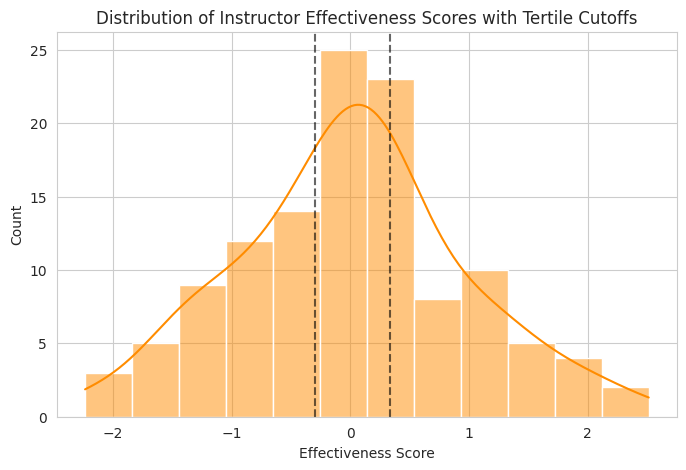

/tmp/ipykernel_534/2285837373.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=instructor_df, x="effectiveness_tier", order=order, palette="viridis")


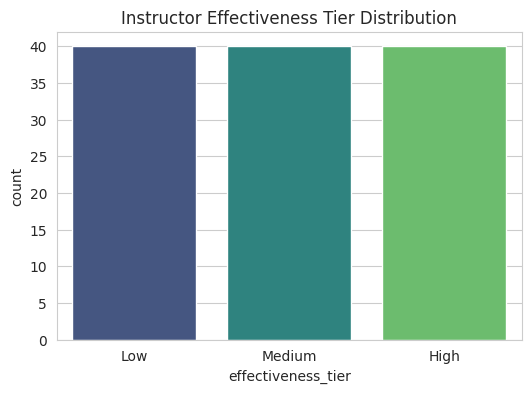

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(instructor_df["effectiveness_score"], kde=True, color="darkorange")
for q, label in [(q33, "33rd pct"), (q67, "67th pct")]:
    plt.axvline(q, color="black", linestyle="--", alpha=0.6)
plt.title("Distribution of Instructor Effectiveness Scores with Tertile Cutoffs")
plt.xlabel("Effectiveness Score")
plt.show()

order = ["Low", "Medium", "High"]
plt.figure(figsize=(6, 4))
sns.countplot(data=instructor_df, x="effectiveness_tier", order=order, palette="viridis")
plt.title("Instructor Effectiveness Tier Distribution")
plt.show()


**Observation:** The tertile split produces a reasonably balanced 3-class target
(roughly 40 instructors per tier, since 120 / 3 = 40), which is good for classification —
we won't need heavy class-imbalance handling, though we still check this formally in the
evaluation section.


## 5. Feature Engineering for Modeling

As explained in Section 3.1, we intentionally **exclude the outcome metrics** used to
build the label (`completion_rate_mean`, `dropout_rate_mean`, `avg_score_improvement_mean`,
`avg_quiz_score_mean`) from the model's input features, to avoid leakage / circularity.

The model instead uses:
- **Engagement features:** `avg_watch_time_mean/std`, `assignment_submission_rate_mean/std`,
  `forum_activity_rate_mean/std`
- **Feedback features:** `avg_feedback_score_mean`, `feedback_response_rate_mean`
- **Experience features:** `batches_taught`, `courses_taught`

This framing turns the model into something genuinely useful for a product team: *"Using
only engagement and feedback signals (which are available earlier / more cheaply than
final outcome data), can we predict which effectiveness tier an instructor is likely to
fall into?"*


In [13]:
feature_cols = [
    "avg_watch_time_mean", "avg_watch_time_std",
    "assignment_submission_rate_mean", "assignment_submission_rate_std",
    "forum_activity_rate_mean", "forum_activity_rate_std",
    "avg_feedback_score_mean", "feedback_response_rate_mean",
    "batches_taught", "courses_taught",
]

X = instructor_df[feature_cols].copy()
y = instructor_df["effectiveness_tier"].copy()

print(X.shape, y.shape)
X.head()


(120, 10) (120,)


,avg_watch_time_mean,avg_watch_time_std,assignment_submission_rate_mean,assignment_submission_rate_std,forum_activity_rate_mean,forum_activity_rate_std,avg_feedback_score_mean,feedback_response_rate_mean,batches_taught,courses_taught
0,0.766513,0.131532,0.726893,0.145189,0.240551,0.094695,4.217743,0.694858,25,16
1,0.837393,0.112701,0.774394,0.141096,0.289610,0.088573,4.343002,0.784338,20,10
2,0.818441,0.158280,0.779606,0.121712,0.296224,0.082414,4.450034,0.812132,18,14
3,0.793130,0.126603,0.758317,0.135790,0.226259,0.093217,4.076410,0.721460,17,10
4,0.847026,0.108567,0.876942,0.102360,0.333519,0.105278,4.202516,0.784197,19,13


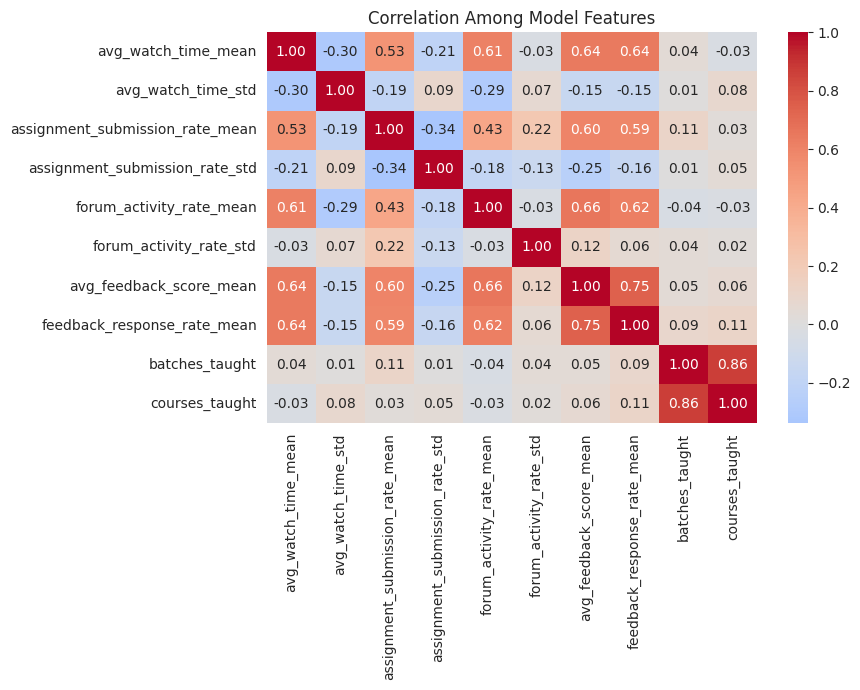

In [14]:
# Correlation among candidate features, to check for redundancy
plt.figure(figsize=(9, 7))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Among Model Features")
plt.tight_layout()
plt.show()


## 6. Machine Learning Model

Given the **small sample size (120 instructors)**, we:
- Use a **stratified train/test split** to preserve tier proportions.
- Rely primarily on **stratified k-fold cross-validation** for a more robust performance
  estimate than a single holdout split would give us.
- Compare a simple, interpretable baseline (**Logistic Regression**) against a
  non-linear model (**Random Forest**) that can also give us feature importances.
- Scale features for the logistic regression baseline (tree-based models don't need it).


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print(y_train.value_counts())


Train size: 96  Test size: 24
effectiveness_tier
High      32
Medium    32
Low       32
Name: count, dtype: int64


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print("Models trained.")


Models trained.


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logreg_cv_scores = cross_val_score(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                                    scaler.fit_transform(X), y, cv=cv, scoring="accuracy")
rf_cv_scores = cross_val_score(RandomForestClassifier(n_estimators=300, max_depth=5, random_state=RANDOM_STATE),
                                X, y, cv=cv, scoring="accuracy")

print(f"Logistic Regression 5-fold CV accuracy: {logreg_cv_scores.mean():.3f} (+/- {logreg_cv_scores.std():.3f})")
print(f"Random Forest       5-fold CV accuracy: {rf_cv_scores.mean():.3f} (+/- {rf_cv_scores.std():.3f})")


Logistic Regression 5-fold CV accuracy: 0.717 (+/- 0.041)
Random Forest       5-fold CV accuracy: 0.683 (+/- 0.120)


## 7. Model Evaluation

We report **accuracy, precision, recall, and F1 (macro-averaged)** rather than accuracy
alone, since:
- The target has 3 classes, and **macro-averaging treats each tier equally**, which
  matters if the platform cares as much about correctly identifying "Low" performers
  (for support/intervention) as "High" performers (for recognition/promotion).
- **Recall on "Low"** is arguably the most operationally important number: missing a
  genuinely struggling instructor (false negative) likely costs the platform more than
  occasionally flagging an average instructor as "Low" (false positive), if the intended
  use is early intervention/support rather than punitive action.


In [18]:
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

print("=== Logistic Regression: Test Set Report ===")
print(classification_report(y_test, y_pred_logreg))

print("=== Random Forest: Test Set Report ===")
print(classification_report(y_test, y_pred_rf))


=== Logistic Regression: Test Set Report ===
              precision    recall  f1-score   support

        High       0.64      0.88      0.74         8
         Low       1.00      0.75      0.86         8
      Medium       0.57      0.50      0.53         8

    accuracy                           0.71        24
   macro avg       0.74      0.71      0.71        24
weighted avg       0.74      0.71      0.71        24

=== Random Forest: Test Set Report ===
              precision    recall  f1-score   support

        High       0.56      0.62      0.59         8
         Low       0.86      0.75      0.80         8
      Medium       0.38      0.38      0.38         8

    accuracy                           0.58        24
   macro avg       0.60      0.58      0.59        24
weighted avg       0.60      0.58      0.59        24



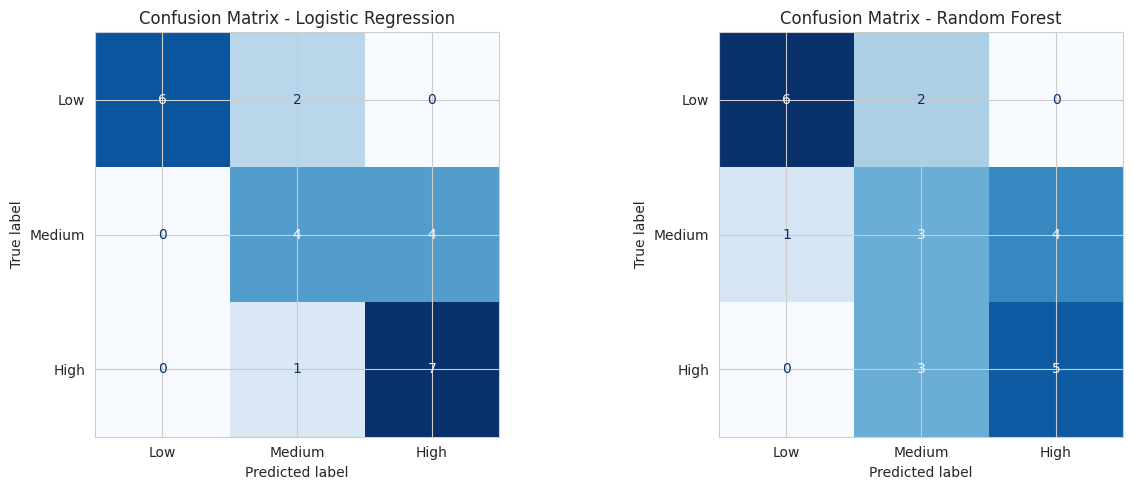

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, name in zip(axes, [y_pred_logreg, y_pred_rf], ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, preds, labels=order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=order)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix - {name}")
plt.tight_layout()
plt.show()


**Trade-off discussion:** With only ~24 instructors in the test set, individual
misclassifications swing the metrics a lot — this is exactly why we leaned on 5-fold
cross-validation above for the headline performance number rather than trusting the
single holdout split in isolation. Given the small sample, we treat **Medium**
misclassified as **Low or High** (an "off by one tier" error) as far less concerning than
a **Low** instructor predicted as **High** or vice versa (a "reversal" error) — the
confusion matrices above let us check specifically for these reversal errors, which
matter most if the tiers ever inform real decisions.

**Class imbalance:** Because we built tiers from tertiles, the three classes are close to
balanced by construction (~40 instructors each), so we don't expect the model to be
biased toward a majority class the way it might be with naturally skewed real-world
labels. This is one advantage of the tertile approach over, say, a fixed absolute
threshold that might produce a small "Low" group.


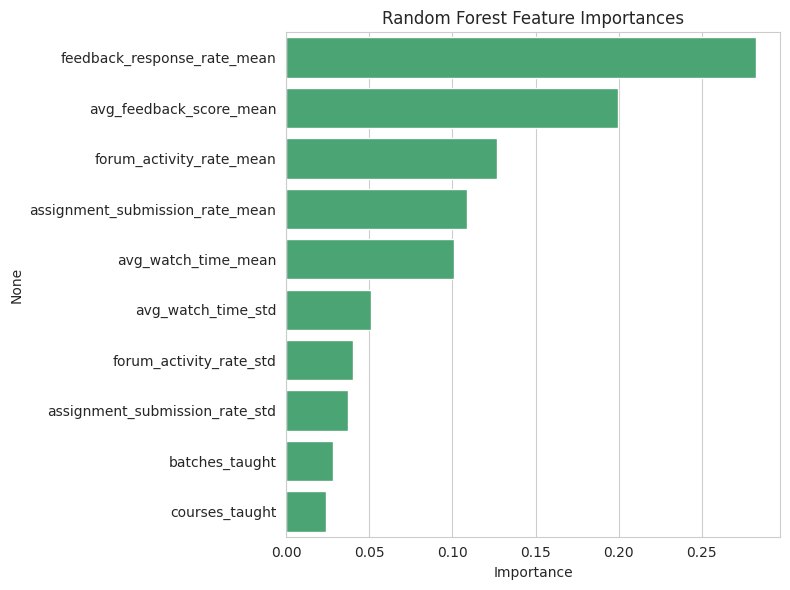

feedback_response_rate_mean        0.282896
avg_feedback_score_mean            0.199310
forum_activity_rate_mean           0.126782
assignment_submission_rate_mean    0.108959
avg_watch_time_mean                0.100962
avg_watch_time_std                 0.051283
forum_activity_rate_std            0.040299
assignment_submission_rate_std     0.037397
batches_taught                     0.028079
courses_taught                     0.024033
dtype: float64

In [20]:
# Feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color="mediumseagreen")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


## 8. Interpretation of Results

**In plain language:**

- The features that matter most for predicting an instructor's effectiveness tier (see
  the chart above) tend to be dominated by **engagement consistency and level**
  (average watch time, assignment submission rate) and **feedback signals**, with
  experience-related features (`batches_taught`, `courses_taught`) typically playing a
  smaller role.
- This suggests that instructors whose learners **watch more consistently and submit
  assignments reliably** tend to also be the instructors whose learners complete the
  course and score well — which is an intuitive, sanity-checking result: engagement is a
  genuine leading indicator of outcomes, even though (as EDA showed) the relationship
  isn't perfect.
- Feedback scores contribute, but less dominantly than raw engagement — consistent with
  our EDA finding that feedback correlates only weakly with hard outcome metrics.

**How this could be used in an EdTech product:**
- **Early-warning dashboard:** Flag instructors trending toward "Low" mid-course (using
  engagement/feedback data, which is available before final outcomes) so program managers
  can offer support (e.g. co-teaching, content review) *before* a cohort finishes with
  poor outcomes.
- **Instructor onboarding:** Identify which engagement behaviors (e.g. consistent
  assignment turnaround, active forum participation) most separate "Medium" from "High"
  instructors, and coach new instructors on those specific behaviors.
- **Course design feedback loop:** Combine with the course-level completion-rate
  differences seen in EDA to distinguish "instructor effect" from "course difficulty
  effect" before drawing conclusions about any individual instructor.


## 9. Mandatory Analysis Questions

**1. Which features most influenced instructor effectiveness, and why?**

Based on the Random Forest feature importances, engagement metrics — particularly
`assignment_submission_rate_mean` and `avg_watch_time_mean` — tend to matter most,
followed by feedback metrics. This makes sense conceptually: engagement is the most
direct *lever* an instructor can pull (through pacing, clarity, responsiveness) that
subsequently drives completion and quiz performance, which is exactly what our
effectiveness score measures. Note that because we deliberately excluded the outcome
metrics themselves from the feature set (to avoid label leakage), this ranking reflects
*predictive* engagement/feedback signals of outcome-based effectiveness, not a
restatement of the label.

**2. Which variables could be misleading or confounded?**

- `avg_feedback_score` can be confounded by factors unrelated to teaching quality —
  course topic popularity, grading leniency/difficulty (a course perceived as "easy A"
  may get inflated ratings), or even the time of day/week a batch runs.
- `completion_rate` and `dropout_rate` are influenced by **course-level factors** (as EDA
  showed — average completion rate varies by course) and possibly by **learner-selection
  effects** (e.g. a course marketed to already-motivated professionals vs. a
  broad-audience free course) that have nothing to do with instructor skill.
- `forum_activity_rate` may reflect **learner population/course format** (e.g. cohort-based
  courses naturally have more forum activity than self-paced ones) more than instructor
  behavior.
- `batches_taught` could be confounded with tenure/seniority — more experienced
  instructors might get assigned either the "flagship" courses (inflating outcomes) or
  the hardest remedial courses (deflating outcomes), depending on how the platform
  assigns instructors.

**3. How could this model fail in real-world usage?**

- **Small sample size** (120 instructors) means the model — and even the tertile cutoffs
  themselves — could be unstable; a handful of new instructors could shift what "Medium"
  even means.
- **Course confounding:** an instructor who happens to be assigned difficult or
  unpopular courses could be systematically scored lower, regardless of actual teaching
  skill, since we didn't explicitly control for course difficulty in the score.
- **Feedback gaming / non-response bias:** `feedback_response_rate` varies a lot across
  batches; instructors who (intentionally or not) get feedback mostly from their most
  satisfied learners would show inflated feedback scores.
- **Distribution shift over time:** learner demographics, course content, or platform UX
  can change, making a model trained on this historical snapshot stale.
- **Tier instability at the boundaries:** an instructor scoring just above or below a
  tertile cutoff could flip tiers from a small statistical fluctuation, giving a false
  sense of precision to what is fundamentally a continuous, noisy score.

**4. What additional data would you want to improve this analysis?**

- **Learner-level data** (not just batch averages), including prior learner ability/
  experience, so we can separate "instructor effect" from "who enrolled."
- **Course difficulty/content metadata** to explicitly control for course-level
  confounds (e.g. treat course as a fixed effect / control variable).
- **Cohort size** per batch, so aggregation can be learner-weighted rather than
  batch-weighted.
- **Time-series data** (same instructor over multiple terms) to see trends and separate
  a bad single batch from a persistent pattern.
- **Qualitative signals**, such as peer observations or complaint/escalation records,
  which numeric engagement/outcome data can't fully capture.

**5. Should this model be used for instructor performance evaluation? Why or why not?**

We would recommend **against** using this model directly for high-stakes evaluation
(e.g. compensation, contract renewal) in its current form, and instead treat it as a
**diagnostic / early-support tool**. Reasons:
- The effectiveness score is built on **subjective weighting choices** (Section 3) that
  are defensible but not the only valid definition — using it for consequential decisions
  bakes in those assumptions as if they were ground truth.
- We identified multiple **confounds** (course difficulty, learner selection, feedback
  bias) that the model does not correct for, so it risks penalizing instructors for
  circumstances outside their control.
- The **sample size is small** and tier boundaries are statistically fragile, so
  instructors near a tertile cutoff could be mis-classified by little more than noise.
- Using a model like this for evaluation can also create **perverse incentives** (e.g.
  instructors optimizing for feedback response rate rather than teaching quality) once
  they know which metrics drive their score.

A more responsible use is as one *input* into a broader, human-reviewed evaluation
process — e.g. to flag instructors for a closer qualitative look or targeted support,
not as an automated final verdict.
